In [31]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from langchain_mcp_adapters.client import MultiServerMCPClient

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import RetryPolicy

from dotenv import load_dotenv

from typing import Optional, Annotated
from pydantic import BaseModel, Field

import os
import asyncio
import json
import time
import re
import requests

import boto3
from typing import Dict, Any

In [32]:
load_dotenv()

True

In [33]:
GITHUB_TOKEN = os.environ["GITHUB_MCP_TOKEN"]

In [34]:
SERVERS = {
    "github": {
        "transport": "http",
        "url": "https://api.githubcopilot.com/mcp/",
        "headers": {
            "Authorization": f"Bearer {GITHUB_TOKEN}"
        }
    }
}

In [35]:
client = MultiServerMCPClient(SERVERS)
tools = await client.get_tools()

In [36]:
class AgentState(MessagesState):

    issue_description: str

    repo_owner: str
    repo_name: str

    branch_name: Optional[str]
    target_file: Optional[str]

    original_file_content: Optional[str]
    modified_file_content: Optional[str]
    fix_description: Optional[str]

    commit_sha: Optional[str]

    ci_status: Optional[str]
    ci_retry_count: Optional[int] = 0
    ci_max_retry_limit: Optional[int] = 2

    pr_number: Optional[int]
    pr_url: Optional[str]

    pr_summary: Optional[str]

    job_id: Optional[str]
    error_message: Optional[str]
    error_logs: Optional[str]

    human_approved: Optional[bool]

In [37]:
git_branch_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
git_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0).bind_tools(tools)
# The PR agent also uses GitHub MCP tools
pr_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0).bind_tools(tools)
# Remediation agent doesn't need external tools, just coding knowledge
remediation_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

In [38]:
tool_node = ToolNode(tools, handle_tool_errors = True)

In [39]:
# Configure it to retry up to 3 times, waiting 5 seconds between attempts
git_retry_policy = RetryPolicy(
    max_attempts=3,
    initial_interval=5.0,  # 5 seconds
    backoff_factor=1.0,    # Keeps the wait exactly at 5 seconds each time
    jitter=False           # Ensures it doesn't randomize the 5 seconds
)

In [40]:
class RemediationOutput(BaseModel):
    script_content: str = Field(
        ..., 
        description="The raw content of the bash script (.sh) containing the commands to fix the vulnerability on the VM. Do not include markdown code block syntax."
    )
    branch_name: str = Field(
        ..., 
        description="A clean, kebab-case branch name for git, e.g., 'patch-vulnerability-cve-xxxx'"
    )
    fix_summary: str = Field(
        ..., 
        description="A concise summary of what changes this script is executing (e.g., upgrading package X to version Y). This will be used in the PR description."
    )

In [41]:
async def remediation_node(state: AgentState):
    print("Executing remediation_node (Generating .sh script)...")
    
    # Bind the structured output schema to the LLM
    structured_llm = remediation_llm.with_structured_output(RemediationOutput)
    
    system_prompt = (
    "You are an automated DevSecOps security agent. Your task is to analyze the cloud vulnerability "
    "provided by the user and generate a production-ready bash script ('remediation.sh') that "
    "will run on a target VM to fix the issue.\n"
    "IMPORTANT: If the vulnerability is inside a compiled language standard library (like Go stdlib) "
    "or an application-level dependency (npm, pip) that cannot be updated via system package managers, "
    "your bash script should safely attempt to log the required remediation steps or update the global environment "
    "runtime (e.g., updating the Go installation on the machine if applicable)."
)
    
    user_prompt = f"Vulnerability Details:\n{state['issue_description']}"
    
    # Invoke the model
    response: RemediationOutput = await structured_llm.ainvoke([
        {"role": "system", "content": system_prompt},
        HumanMessage(content=user_prompt)
    ])
    
    # Return the keys to update the global AgentState
    # This maps 'script_content' into your state's 'modified_file_content'
    print(f"\n\nGENERATED SCRIPT:\n\n{response.script_content}\n\n")
    return {
        "modified_file_content": response.script_content,
        "branch_name": response.branch_name,
        "fix_description": response.fix_summary,
        "target_file": "remediation.sh" # Keeping track of the filename explicitly
    }

In [42]:
async def create_prompt(state: AgentState):
    print("Executing create_prompt...")
    prompt = (
            f"Using your GitHub tools, execute the following actions sequentially on the repository "
            f"'{state['repo_owner']}/{state['repo_name']}':\n\n"
            f"1. Create a new branch named '{state['branch_name']}' from the default branch.\n"
            f"2. Create or update a file named '{state['target_file']}' in the root of the repository.\n"
            f"3. Write the following content exactly into that file:\n"
            f"-----------\n"
            f"{state['modified_file_content']}\n"
            f"-----------\n"
            f"4. Commit with a suitable message\n"
            f"5. Create a Pull Request to the default branch.\n"
            f"   Title: <Give suitable title>\n"
            f"   Body:\n"
            f"   This PR introduces an automated remediation script.\n\n"
            f"   Fix Summary: {state['fix_description']}\n\n"
            f"When all steps are complete, return ONLY:\n"
            f"1. commit sha\n"
            f"2. pr_url\n"
            f"3. pr_number"
            f"""You MUST continue calling tools until:
1. Branch is created
2. File is committed
3. Pull request is created

Do not stop early.
Do not summarize intermediate results.
Only return a final message after the PR has been created."""
    )
    return {"messages": [HumanMessage(content = prompt)]}

In [43]:
async def git_operator_node(state: AgentState):
    print(f"Executing git_operator_node (Pushing {state['target_file']} and creating PR)...")
    response = await git_llm.ainvoke(state['messages'])
    return {"messages": [response]}

In [44]:
class GitWorkflowOutput(BaseModel):
    commit_sha: str = Field(..., description = "Commit SHA")
    pr_url: str = Field(..., description = "URL of the PR")
    pr_number: int = Field(..., description = "PR Number")

commit_pr_extractor_llm = ChatOpenAI(model = "gpt-4.1-mini", temperature = 0).with_structured_output(GitWorkflowOutput)

In [45]:
async def extract_pr_details(state: AgentState):
    print("Extracting commit SHA and PR details...")

    details = await commit_pr_extractor_llm.ainvoke([HumanMessage(
        content = f"""
Extract the commit sha, PR URL and PR Number from the given LLM response:
{state['messages'][-1].content}
"""
    )])

    return {
        "commit_sha": details.commit_sha,
        "pr_url": details.pr_url,
        "pr_number": details.pr_number
    }

In [46]:
async def check_ci_status(state: AgentState):
    print("Executing check_ci_status node")
    pr_tool = next(t for t in tools if t.name == "pull_request_read")

    timeout_seconds = 900   # 15 minutes max
    start_time = time.time()

    while True:
        result = await pr_tool.ainvoke({
            "method": "get_check_runs",
            "owner": state["repo_owner"],
            "repo": state["repo_name"],
            "pullNumber": state["pr_number"]
        })

        data = json.loads(result[0]["text"])
        check_runs = data.get("check_runs", [])

        # No checks yet → CI may still be initializing
        if len(check_runs) == 0:
            if time.time() - start_time > timeout_seconds:
                return {"ci_status": "failure"}
            await asyncio.sleep(10)
            continue

        statuses = [run["status"] for run in check_runs]

        # Wait if any check still running
        if any(s != "completed" for s in statuses):
            if time.time() - start_time > timeout_seconds:
                return {"ci_status": "failure"}
            await asyncio.sleep(10)
            continue

        conclusions = [run["conclusion"] for run in check_runs]

        # All completed → determine result
        if all(c == "success" for c in conclusions):
            job_id = data["check_runs"][0]["html_url"].split("/")[-1].strip()
            return {"ci_status": "success", "job_id": job_id}
        else:
            job_id = data["check_runs"][0]["html_url"].split("/")[-1].strip()
            return {"ci_status": "failure", "job_id": job_id}

In [47]:
async def route_after_ci(state: AgentState):
    return state['ci_status']

In [48]:
async def fetch_and_purge_latest_logs(state: AgentState) -> Dict[str, Any]:
    print("--- EXECUTING LOG RETRIEVAL & S3 PURGE NODE ---")
    s3_client = boto3.client('s3')
    
    bucket_name = "remediation-logs-bucket" 
    
    raw_branch = state.get("branch_name", "")
    if not raw_branch:
        return {"error_logs": "Execution failed: branch_name key not found in agent state."}
        
    clean_branch = raw_branch.replace("/", "-")
    prefix = f"remediation-runs/{clean_branch}/"
    
    # --- PHASE 1: FETCHING LOGS ---
    try:
        print(f"Scanning S3 location: s3://{bucket_name}/{prefix}")
        response = s3_client.list_objects_v2(Bucket=bucket_name, Prefix=prefix)
        
        if 'Contents' not in response:
            return {"error_logs": "No logs found in S3 for this branch run."}
            
        all_objects = response['Contents']
        stderr_obj = next((obj for obj in all_objects if obj['Key'].endswith('/stderr')), None)
        stdout_obj = next((obj for obj in all_objects if obj['Key'].endswith('/stdout')),None)
        
        target_obj = stderr_obj if stderr_obj else stdout_obj
        if not target_obj:
            return {"error_logs": "Log directory exists, but target execution files were missing."}
            
        log_key = target_obj['Key']
        print(f"Downloading logs from: {log_key}")
        
        log_file = s3_client.get_object(Bucket=bucket_name, Key=log_key)
        error_logs = log_file['Body'].read().decode('utf-8')
        
    except Exception as e:
        error_msg = f"S3 Fetch Error: Failed to fetch/read logs from S3. Details: {str(e)}"
        print(f"CRITICAL: {error_msg}")
        return {"error_logs": error_msg}

    # --- PHASE 2: CLEARING LOGS ---
    try:
        # Map objects to expected S3 deletion structure
        objects_to_delete = [{'Key': obj['Key']} for obj in all_objects]
        print(f"Purging {len(objects_to_delete)} log files from s3://{bucket_name}/{prefix}...")
        
        # Safe Chunking: S3 batch deletes allow a maximum of 1,000 keys per request
        for i in range(0, len(objects_to_delete), 1000):
            chunk = objects_to_delete[i:i + 1000]
            s3_client.delete_objects(
                Bucket=bucket_name,
                Delete={'Objects': chunk}
            )
        print("S3 runway completely cleared.")
        
    except Exception as e:
        error_msg = f"S3 Clear Error: Logs were read successfully, but failed to clear/delete them from S3. Details: {str(e)}"
        print(f"CRITICAL: {error_msg}")
        return {"error_logs": f"{error_logs}\n\n[SYSTEM WARNING] {error_msg}"}
        
    return {"error_logs": error_logs}

In [49]:
async def build_graph():
    graph = StateGraph(AgentState)

    graph.add_node("remediation_node", remediation_node)
    graph.add_node("create_prompt", create_prompt)
    graph.add_node("git_operator_node", git_operator_node, retry_policy=git_retry_policy)
    graph.add_node("github_tools", tool_node)
    graph.add_node("extract_pr_details", extract_pr_details)
    graph.add_node("check_ci_status", check_ci_status)
    graph.add_node("fetch_and_purge_latest_logs", fetch_and_purge_latest_logs)

    graph.add_edge(START, "remediation_node")
    graph.add_edge("remediation_node", "create_prompt")
    graph.add_edge("create_prompt", "git_operator_node")
    graph.add_conditional_edges("git_operator_node", tools_condition, {"tools": "github_tools", "__end__": "extract_pr_details"})
    graph.add_edge("github_tools", "git_operator_node")
    graph.add_edge("extract_pr_details", "check_ci_status")
    graph.add_conditional_edges("check_ci_status", route_after_ci, {"success": "__end__", "failure": "fetch_and_purge_latest_logs"})

    chatbot = graph.compile(checkpointer=InMemorySaver())
    return chatbot

In [50]:
github_workflow = await build_graph()

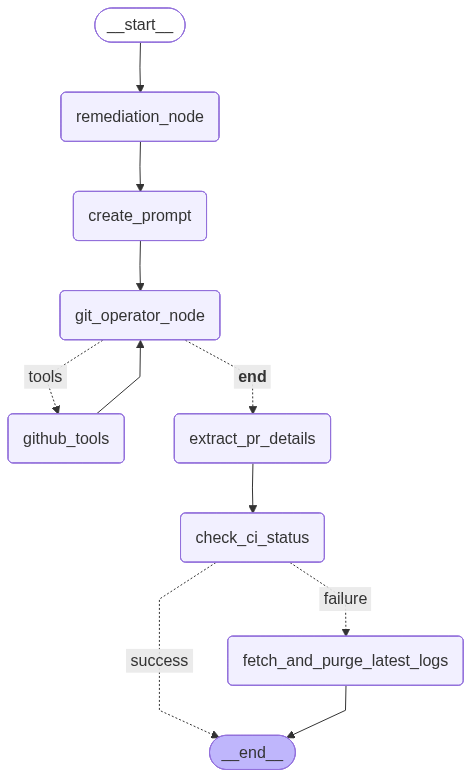

In [51]:
github_workflow

In [52]:
CONFIG = {"configurable": {"thread_id": "thread-1"}}

In [ ]:
result = await github_workflow.ainvoke(
    {
        "issue_description": """
ID: CVE-2026-3593
Package Name: bind9-dnsutils
Ecosystem/PURL: pkg:deb/ubuntu/bind9-dnsutils@9.20.18-1ubuntu2?arch=amd64&distro=ubuntu-26.04&epoch=1
Installed Version: 1:9.20.18-1ubuntu2
Fixed Version: 1:9.20.18-1ubuntu2.1
Title: bind: Heap use-after-free vulnerability in BIND 9 DNS-over-HTTPS implementation
Description: A use-after-free vulnerability exists within the DNS-over-HTTPS implementation. This issue affects BIND 9 versions 9.20.0 through 9.20.22, 9.21.0 through 9.21.21, and 9.20.9-S1 through 9.20.22-S1. BIND 9 versions 9.18.0 through 9.18.48 and 9.18.11-S1 through 9.18.48-S1 are NOT affected.
Severity: MEDIUM
CVSS Score: 7.4 (RedHat) / 9.8 (NVD)
CWE IDs: CWE-416
Primary URL: https://avd.aquasec.com/nvd/cve-2026-3593
References:
- https://access.redhat.com/security/cve/CVE-2026-3593
- https://downloads.isc.org/isc/bind9/9.20.23
- https://downloads.isc.org/isc/bind9/9.21.22
- https://kb.isc.org/docs/cve-2026-3593
- https://nvd.nist.gov/vuln/detail/CVE-2026-3593
- https://ubuntu.com/security/notices/USN-8293-1
- https://www.cve.org/CVERecord?id=CVE-2026-3593
""",
        "repo_owner": "Rahul-Data-Scientist",
        "repo_name": "vulnerability-remediation",
        "target_file": "remediation.sh",
        "messages": []
    },
    config=CONFIG
)

Executing remediation_node (Generating .sh script)...


GENERATED SCRIPT:

#!/bin/bash
set -e

# Update package lists
apt-get update

# Install the fixed version of bind9-dnsutils package
apt-get install -y bind9-dnsutils=1:9.20.18-1ubuntu2.1

# Hold the package to prevent unintended downgrades (optional)
apt-mark hold bind9-dnsutils

# Verify the installed version
installed_version=$(dpkg-query -W -f='${Version}' bind9-dnsutils)
echo "Installed bind9-dnsutils version: $installed_version"

if [[ "$installed_version" == "1:9.20.18-1ubuntu2.1" ]]; then
  echo "bind9-dnsutils successfully updated to the fixed version."
else
  echo "Failed to update bind9-dnsutils to the fixed version." >&2
  exit 1
fi



Executing create_prompt...
Executing git_operator_node (Pushing remediation.sh and creating PR)...
Executing git_operator_node (Pushing remediation.sh and creating PR)...
Executing git_operator_node (Pushing remediation.sh and creating PR)...
Executing git_operator_node (Pushing remediati

In [54]:
# def fetch_pr_feedback(owner, repo, pr_number):
#     # 1. Setup authentication headers using your environment variable
#     token = os.environ.get('GITHUB_MCP_TOKEN')
#     if not token:
#         print("Warning: GITHUB_MCP_TOKEN environment variable not found. Running unauthenticated.")
    
#     headers = {
#         "Accept": "application/vnd.github+json",
#         "X-GitHub-Api-Version": "2022-11-28"
#     }
#     if token:
#         headers["Authorization"] = f"Bearer {token}"

#     base_url = f"https://api.github.com/repos/{owner}/{repo}"
    
#     print(f"=== Fetching Feedback for PR #{pr_number} ===")

#     # -------------------------------------------------------------------------
#     # PART 1: Fetch General Conversation Comments (Timeline Chat)
#     # -------------------------------------------------------------------------
#     general_comments_url = f"{base_url}/issues/{pr_number}/comments"
#     general_response = requests.get(general_comments_url, headers=headers)
    
#     print("\n--- General Timeline Comments ---")
#     if general_response.status_code == 200:
#         comments = general_response.json()
#         if not comments:
#             print("No general timeline comments found.")
#         for c in comments:
#             print(f"[{c['user']['login']}]: {c['body']}\n")
#     else:
#         print(f"Failed to fetch general comments. Status: {general_response.status_code}")

#     # -------------------------------------------------------------------------
#     # PART 2: Fetch Structured Reviews and Inline Code Comments
#     # -------------------------------------------------------------------------
#     reviews_url = f"{base_url}/pulls/{pr_number}/reviews"
#     reviews_response = requests.get(reviews_url, headers=headers)
    
#     print("\n--- Structured Code Reviews & Line Feedback ---")
#     if reviews_response.status_code == 200:
#         reviews = reviews_response.json()
#         if not reviews:
#             print("No structured reviews found.")
            
#         for r in reviews:
#             # Capture official rejections (CHANGES_REQUESTED) and standard review notes (COMMENTED)
#             if r['state'] in ['CHANGES_REQUESTED', 'COMMENTED']:
#                 print(f"\n>> Review by {r['user']['login']} Status: ({r['state']})")
#                 if r['body']:
#                     print(f"   Summary: {r['body']}")
                
#                 # Fetch the individual line-by-line comments tied specifically to this review ID
#                 review_id = r['id']
#                 inline_url = f"{base_url}/pulls/{pr_number}/reviews/{review_id}/comments"
#                 inline_response = requests.get(inline_url, headers=headers)
                
#                 if inline_response.status_code == 200:
#                     inline_comments = inline_response.json()
#                     for comment in inline_comments:
#                         # Bulletproof fallback chain to grab the right line number
#                         line_number = comment.get('line') or comment.get('original_line') or comment.get('position')
#                         print(f"    - File: {comment['path']} (Line {line_number})")
#                         print(f"      Feedback: {comment['body']}")
#                 else:
#                     print(f"    Could not fetch inline comments for review {review_id}.")
#     else:
#         print(f"Failed to fetch reviews. Status: {reviews_response.status_code}")

In [55]:
# fetch_pr_feedback(
#     owner="Rahul-Data-Scientist",
#     repo="HPE-Project",
#     pr_number=5
# )

In [56]:
# pr_tool = next(t for t in tools if t.name == "pull_request_read")

# result = await pr_tool.ainvoke({
#     "method": "get",
#     "owner": "Rahul-Data-Scientist",
#     "repo": "HPE-Project",
#     "pullNumber": 7
# })

In [57]:
# data = json.loads(result[0]['text'])
# print("PR Merged?", data['merged'])
# print("PR State:", data['state'])